# EU-OS bioactives → AnnData

Builds an AnnData object from the well-level CellProfiler profiles of the
[EU-OPENSCREEN bioactives Cell Painting dataset](https://github.com/schmiedc/EU-OS_bioactives)
([Wolff et al. 2024](https://doi.org/10.1101/2024.08.27.609964)): the ~2500 EU-OPENSCREEN
bioactive compounds imaged at four sites (FMP, IMTM, MEDINA, USC) across two cell lines
(U2OS, HepG2). One observation is a well, one variable is a CellProfiler feature.

The aggregated profiles and the well/compound annotations are published on
[Zenodo](https://doi.org/10.5281/zenodo.13309566) and fetched on first use:

* `Aggregated_Profiles.zip` — per-well median profiles, one CSV per plate and replicate,
  grouped into `aggregated_data/<SITE>_<CELL_LINE>/`.
* `Profile_Analysis.zip` — the `annotations/` tables that map a well to its EU-OPENSCREEN
  compound id and that compound to its structure and annotated targets.

The raw images live in the [Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/)
under `cpg0036-EU-OS-bioactives` and are not needed here.

In [1]:
from __future__ import annotations

import io
import zipfile
from collections.abc import Iterable, Sequence
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

DATA_ROOT = Path("~/data/eu-os-bioactives").expanduser()
SUBSET = "IMTM_HepG2"  # <SITE>_<CELL_LINE>: FMP_HepG2, FMP_U2OS, IMTM_HepG2, MEDINA_HepG2, USC_HepG2

ZENODO = "https://zenodo.org/api/records/13309566/files"
SITE, CELL_LINE = SUBSET.split("_", 1)

## Loading a subset

Each `<SITE>_<CELL_LINE>` folder holds one CSV per physical plate — seven
EU-OPENSCREEN library plates (`B1001`–`B1007`), each imaged as four replicate
plates (`R1`–`R4`). A CSV is already collapsed to one row per well: single cells
were segmented with a CellProfiler pipeline and reduced to a per-well median, so
the feature columns (`Nuc_`, `Cells_`, `Cyto_`) are still named measurements.

These are *raw* aggregated profiles — no normalization yet — so combining
subsets later only needs the variables intersected; the per-plate normalization
happens further down.

In [2]:
def fetch_zip(name: str, root: Path, marker: str) -> None:
    """Download and unpack a Zenodo archive unless `marker` already exists under `root`."""
    if (root / marker).exists():
        return
    from urllib.request import urlopen

    root.mkdir(parents=True, exist_ok=True)
    url = f"{ZENODO}/{name}/content"
    print(f"fetching {url}")
    with urlopen(url) as resp:  # Zenodo, https only
        payload = resp.read()
    with zipfile.ZipFile(io.BytesIO(payload)) as zf:
        zf.extractall(root)


def _split_plate_replicate(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize the two plate-naming conventions to explicit Plate / Replicate columns."""
    plate = df["Metadata_Plate"].astype(str)
    if plate.str.contains("_").any():  # e.g. "B1001_R1"; Metadata_Batch is then just the cell/dose tag
        parts = plate.str.rsplit("_", n=1, expand=True)
        df = df.assign(Metadata_Plate=parts[0].to_numpy(), Metadata_Replicate=parts[1].to_numpy())
    else:  # FMP_HepG2: Metadata_Plate is "B1001" and Metadata_Batch is the replicate
        df = df.assign(Metadata_Replicate=df["Metadata_Batch"].astype(str))
    return df.copy()  # de-fragment after widening a ~3k-column frame


def load_profiles(root: Path, subset: str) -> ad.AnnData:
    fetch_zip("Aggregated_Profiles.zip", root, f"aggregated_data/{subset}")
    paths = sorted((root / "aggregated_data" / subset).glob("*_CP_Profiles_Aggregated.csv"))
    if not paths:
        raise FileNotFoundError(f"no aggregated CSVs for {subset!r}")
    df = pd.concat((pd.read_csv(p) for p in paths), ignore_index=True)
    df = _split_plate_replicate(df)

    feature_cols = [c for c in df.columns if c.split("_", 1)[0] in ("Nuc", "Cells", "Cyto")]
    obs = pd.DataFrame(
        {
            "Site": SITE,
            "CellLine": CELL_LINE,
            "Plate": df["Metadata_Plate"].to_numpy(),
            "Replicate": df["Metadata_Replicate"].to_numpy(),
            "Well": df["Metadata_Well"].to_numpy(),
            "cell_count": df["Metadata_Object_Count"].to_numpy(),
        }
    )
    obs.index = pd.Index(obs["Site"] + ":" + obs["Plate"] + ":" + obs["Replicate"] + ":" + obs["Well"], name="well")
    var = pd.DataFrame(index=pd.Index(feature_cols, name="feature"))

    adata = ad.AnnData(X=df[feature_cols].to_numpy(np.float32), obs=obs, var=var)
    adata.uns["provenance"] = {
        "dataset": "EU-OS bioactives",
        "doi": "10.5281/zenodo.13309566",
        "subset": subset,
        "n_plate_csvs": len(paths),
    }
    return adata


adata = load_profiles(DATA_ROOT, SUBSET)
adata

/var/folders/dy/0ztxj7hd3h3cz5ghg9zsd3bh0000gn/T/ipykernel_37164/4060022532.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(Metadata_Plate=parts[0].to_numpy(), Metadata_Replicate=parts[1].to_numpy())


AnnData object with n_obs × n_vars = 10668 × 2977
    obs: 'Site', 'CellLine', 'Plate', 'Replicate', 'Well', 'cell_count'
    uns: 'provenance'
    layers: None (.X)

## Well and plate annotation

The profiles carry only plate, replicate, and well. The per-subset annotation
table in `annotations/` resolves each well to an EU-OPENSCREEN compound id
(`Metadata_EOS`) and the dose it was screened at. Three values of `Metadata_EOS`
are controls rather than library compounds: `DMSO` is the negative control,
`Nocodazole` and `Tetrandrine` are the positive (tubulin-disrupting) controls.

In [3]:
ANNOTATION_FILE = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "FMP_U2OS": "2023-05-23_Annotation_Bioactives_U2OS_Corrected.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv",
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}
POSITIVE_CONTROLS = ("Nocodazole", "Tetrandrine")


def read_annotation(root: Path, name: str) -> pd.DataFrame:
    fetch_zip("Profile_Analysis.zip", root, "annotations")
    return pd.read_csv(root / "annotations" / name)


def add_well_metadata(adata: ad.AnnData, root: Path, subset: str) -> None:
    ann = read_annotation(root, ANNOTATION_FILE[subset]).rename(
        columns={
            "Metadata_Plate": "Plate",
            "Metadata_Batch": "Replicate",
            "Metadata_Well": "Well",
            "Metadata_EOS": "EOS",
            "Metadata_Concentration": "concentration_uM",
        }
    )
    ann = ann[["Plate", "Replicate", "Well", "EOS", "concentration_uM"]]
    adata.obs = adata.obs.join(ann.set_index(["Plate", "Replicate", "Well"]), on=["Plate", "Replicate", "Well"])

    pert_type = np.where(
        adata.obs["EOS"].eq("DMSO"),
        "negcon",
        np.where(adata.obs["EOS"].isin(POSITIVE_CONTROLS), "poscon", "trt"),
    )
    adata.obs["pert_type"] = pd.Categorical(pert_type, categories=["negcon", "poscon", "trt"])


def categorize(adata: ad.AnnData, columns: Iterable[str]) -> None:
    for column in columns:
        adata.obs[column] = adata.obs[column].astype("category")


add_well_metadata(adata, DATA_ROOT, SUBSET)
categorize(adata, ["Site", "CellLine", "Plate", "Replicate", "Well", "EOS"])
adata.obs.head()

,Site,CellLine,Plate,Replicate,Well,cell_count,EOS,concentration_uM,pert_type
well,,,,,,,,,
IMTM:B1001:R1:A01,IMTM,HepG2,B1001,R1,A01,401,EOS100001,10,trt
IMTM:B1001:R1:A02,IMTM,HepG2,B1001,R1,A02,960,EOS100089,10,trt
IMTM:B1001:R1:A03,IMTM,HepG2,B1001,R1,A03,684,EOS100009,10,trt
IMTM:B1001:R1:A04,IMTM,HepG2,B1001,R1,A04,1085,EOS100097,10,trt
IMTM:B1001:R1:A05,IMTM,HepG2,B1001,R1,A05,91,EOS100017,10,trt


## Compound annotation

`annotations/` also carries the probes & drugs export for the library. Two hops
get from the well's `EOS` id to chemistry and biology: `EOS_pdid` maps it to a
probes & drugs id, and the compound / target tables key off that — structure and
physicochemical properties from one, the annotated protein targets (collapsed to
a gene-symbol list) from the other. A separate table flags the 20 compounds
whose annotated mechanism is tubulin binding. Controls have no `pdid` and stay
unannotated here.

In [4]:
def add_compound_metadata(adata: ad.AnnData, root: Path) -> None:
    fetch_zip("Profile_Analysis.zip", root, "annotations")
    ann = root / "annotations"

    eos_pdid = pd.read_csv(ann / "2024-08-02_EOS_pdid.csv").rename(
        columns={"Metadata_EOS": "EOS", "Metadata_pdid": "pdid"}
    )
    tubulin = pd.read_csv(ann / "2024-08-02_Tubulin.csv").rename(
        columns={"Metadata_pdid": "pdid", "Metadata_tubulin": "tubulin_binder"}
    )
    compounds = pd.read_csv(ann / "pd_export_04_2022_2464_compounds_standardized.csv")[
        ["pdid", "name", "inchikey", "smiles", "mw", "logp", "approved drug"]
    ].rename(columns={"name": "compound", "approved drug": "approved_drug"})
    compounds["approved_drug"] = compounds["approved_drug"].eq(1)

    targets = pd.read_csv(
        ann / "pd_export_04_2022_2464_targets_standardized.csv", usecols=["pdid", "gene_name"]
    ).dropna(subset=["gene_name"])
    target_genes = targets.groupby("pdid")["gene_name"].agg(lambda s: ";".join(sorted(set(s))))

    meta = (
        eos_pdid.merge(compounds, on="pdid", how="left")
        .merge(tubulin, on="pdid", how="left")
        .merge(target_genes.rename("target_genes"), on="pdid", how="left")
        .drop_duplicates("EOS")
        .set_index("EOS")
    )
    adata.obs = adata.obs.join(meta, on="EOS")
    for col in ("pdid", "compound", "inchikey", "smiles", "target_genes"):
        adata.obs[col] = adata.obs[col].astype("string").fillna("")
    adata.obs["approved_drug"] = adata.obs["approved_drug"].fillna(False).astype(bool)
    adata.obs["tubulin_binder"] = adata.obs["tubulin_binder"].fillna(False).astype(bool)


add_compound_metadata(adata, DATA_ROOT)
categorize(adata, ["pdid", "compound"])
adata.obs.drop(columns=["smiles"]).head()

,Site,CellLine,Plate,Replicate,Well,cell_count,EOS,concentration_uM,pert_type,pdid,compound,inchikey,mw,logp,approved_drug,tubulin_binder,target_genes
well,,,,,,,,,,,,,,,,,
IMTM:B1001:R1:A01,IMTM,HepG2,B1001,R1,A01,401,EOS100001,10,trt,PD003310,vincristine,OGWKCGZFUXNPDA-CFWMRBGOSA-N,824.40,3.52,True,True,NR0B1;NR5A1;TUBA4A;TUBB5
IMTM:B1001:R1:A02,IMTM,HepG2,B1001,R1,A02,960,EOS100089,10,trt,PD056290,TYROSOL,YCCILVSKPBXVIP-UHFFFAOYSA-N,138.07,0.93,False,False,CA2;CAN2;MTCA1;NCE103
IMTM:B1001:R1:A03,IMTM,HepG2,B1001,R1,A03,684,EOS100009,10,trt,PD051680,Netazepide,YDZYKNJZCVIKPP-VWLOTQADSA-N,498.24,4.07,False,False,CCKAR;CCKBR
IMTM:B1001:R1:A04,IMTM,HepG2,B1001,R1,A04,1085,EOS100097,10,trt,PD079971,DIPROTIN A,JNTMAZFVYNDPLB-PEDHHIEDSA-N,341.23,0.97,False,False,DPP4;DPP8;TPP2
IMTM:B1001:R1:A05,IMTM,HepG2,B1001,R1,A05,91,EOS100017,10,trt,PD001019,AMSACRINE,XCPGHVQEEXUHNC-UHFFFAOYSA-N,393.11,4.51,True,False,ABCC4;ALDH1A1;AOX1;APEX1;BLM;CASP1;CASP7;CHRM1...


## Feature annotation

`adata.var` is derived from the feature names alone and can be dropped without
touching the matrix. CellProfiler names follow
`<compartment>_<family>_<measurement>[_<channel>][_<parameters>]`, with
compartment abbreviated here to `Nuc` / `Cells` / `Cyto`.

This is a four-channel Cell Painting stain — `DNA`, `ER`, `AGP`, `Mito` — with no
separate RNA channel. `Correlation` features name a channel *pair*; `AreaShape`,
`Neighbors`, and the mitochondrial-skeleton (`ObjectSkeleton`) features have no
channel. Texture scale/angle, granularity scale, and radial bin are not
extracted.

In [5]:
CHANNELS: Sequence[str] = ("DNA", "ER", "AGP", "Mito")
COMPARTMENTS = {"Nuc": "Nuclei", "Cells": "Cells", "Cyto": "Cytoplasm"}


def annotate_features(var: pd.DataFrame, channels: Sequence[str] = CHANNELS) -> None:
    tokens = [name.split("_") for name in var.index]
    lookup = {c.lower(): c for c in channels}
    matched = [[lookup[t.lower()] for t in token if t.lower() in lookup] for token in tokens]
    var["compartment"] = pd.Categorical([COMPARTMENTS[t[0]] for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([c[0] if c else None for c in matched])
    var["channel_2"] = pd.Categorical([c[1] if len(c) > 1 else None for c in matched])
    var["n_channels"] = np.array([len(c) for c in matched], dtype=np.int8)


annotate_features(adata.var)
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Nuc_AreaShape_Area,Nuclei,AreaShape,NaN,NaN,0
Nuc_AreaShape_BoundingBoxArea,Nuclei,AreaShape,NaN,NaN,0
Nuc_AreaShape_BoundingBoxMaximum_X,Nuclei,AreaShape,NaN,NaN,0
Nuc_AreaShape_BoundingBoxMaximum_Y,Nuclei,AreaShape,NaN,NaN,0
Nuc_AreaShape_BoundingBoxMinimum_X,Nuclei,AreaShape,NaN,NaN,0
...,...,...,...,...,...
Cyto_Texture_Variance_Mito_3_03_256,Cytoplasm,Texture,Mito,NaN,1
Cyto_Texture_Variance_Mito_5_00_256,Cytoplasm,Texture,Mito,NaN,1
Cyto_Texture_Variance_Mito_5_01_256,Cytoplasm,Texture,Mito,NaN,1


`AreaShape` bounding-box corners, object centroids, and nearest-neighbour object
ids encode a cell's position in its field of view, not its phenotype. Drop them.

In [6]:
_BOOKKEEPING = ("BoundingBox", "Center_X", "Center_Y", "Location", "ObjectNumber")
keep = [not any(tok in name for tok in _BOOKKEEPING) for name in adata.var_names]
adata = adata[:, keep].copy()

## Normalization

Each replicate plate is normalized on its own, against its DMSO wells: subtract
the DMSO median and divide by the DMSO MAD (scaled to a standard deviation),
feature by feature — `pycytominer`'s `mad_robustize`. The result is a robust
z-score against the plate's negative controls. The raw medians are kept in
`adata.layers["aggregated"]`.

A feature that is constant across some plate's DMSO wells has zero MAD there and
goes to NaN on that plate; rather than impute, any feature left non-finite on
even one plate is dropped from the whole object.

In [7]:
def mad_robustize(adata: ad.AnnData, group_keys: Sequence[str], control_mask: np.ndarray) -> None:
    adata.layers["aggregated"] = adata.X.copy()
    X = adata.X.astype(np.float64)
    out = np.full_like(X, np.nan)
    groups = adata.obs.groupby(list(group_keys), observed=True).indices
    for idx in groups.values():
        ref = X[np.intersect1d(idx, np.flatnonzero(control_mask))]
        median = np.median(ref, axis=0)
        mad = np.median(np.abs(ref - median), axis=0) * 1.4826
        scale = np.where(mad == 0, np.nan, mad)
        out[idx] = (X[idx] - median) / scale
    adata.X = out.astype(np.float32)


mad_robustize(adata, ("Plate", "Replicate"), adata.obs["pert_type"].eq("negcon").to_numpy())

finite_cols = np.isfinite(adata.X).all(axis=0)
print(f"dropping {int((~finite_cols).sum())} features with zero MAD on some plate")
adata = adata[:, finite_cols].copy()

dropping 174 features with zero MAD on some plate


## Sanity checks

Well counts fall short of 384 per plate where segmentation failed outright
(dead or empty wells); those are simply absent from the aggregated CSVs.

In [8]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"replicates: {sorted(adata.obs['Replicate'].unique())}")
print(
    f"wells per plate x replicate: {sorted(adata.obs.groupby(['Plate', 'Replicate'], observed=True).size().unique())}"
)
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(f"unique compounds: {adata.obs['EOS'].nunique()}  (incl. controls)")
print(adata.obs["pert_type"].value_counts())

10,668 wells x 2,776 features across 7 plates
replicates: ['R1', 'R2', 'R3', 'R4']
wells per plate x replicate: [np.int64(378), np.int64(379), np.int64(380), np.int64(381), np.int64(382), np.int64(383), np.int64(384)]
non-finite values: 0
unique compounds: 2459  (incl. controls)
pert_type
trt       9772
negcon     784
poscon     112
Name: count, dtype: int64


In [9]:
adata.write_h5ad(DATA_ROOT / f"eu_os_{SUBSET.lower()}.h5ad")

## UMAP

The profiles are already per-plate robust z-scores, so they enter PCA unscaled.

In [10]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/luisheinzlmeier/Desktop/cellpainting/WS1/cell-painting-io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A UMAP of these profiles is easy to over-read, so measure the structure before
looking at it. How often do neighbouring wells share a label, against the rate
expected if labels were shuffled?

In [11]:
def neighbour_enrichment(adata: ad.AnnData, keys: Iterable[str]) -> pd.DataFrame:
    graph = adata.obsp["connectivities"].tocoo()
    rows = []
    for key in keys:
        labels = adata.obs[key].to_numpy()
        observed = float((labels[graph.row] == labels[graph.col]).mean())
        baseline = float((adata.obs[key].value_counts(normalize=True).to_numpy() ** 2).sum())
        rows.append({"covariate": key, "observed": observed, "baseline": baseline, "ratio": observed / baseline})
    return pd.DataFrame(rows).set_index("covariate").round(3)


neighbour_enrichment(adata, ["Plate", "Replicate", "pert_type", "EOS"])

,observed,baseline,ratio
covariate,,,
Plate,0.345,0.143,2.416
Replicate,0.323,0.250,1.291
pert_type,0.887,0.845,1.050
EOS,0.080,0.006,13.726


By ratio, same-compound wells are by far the most enriched (~14x over chance):
the four replicates of a compound sit at one library position and reproduce
well. Same-plate wells come next (~2.4x) — plate geometry survives the per-plate
normalization — while `pert_type` is barely above its (already high) baseline.
In absolute terms neighbouring wells still share a specific compound only ~8% of
the time: most bioactives at this dose move morphology too little to pull apart.
This is why the study scores compounds by replicate reproducibility and
induction rather than by clustering the profiles directly.

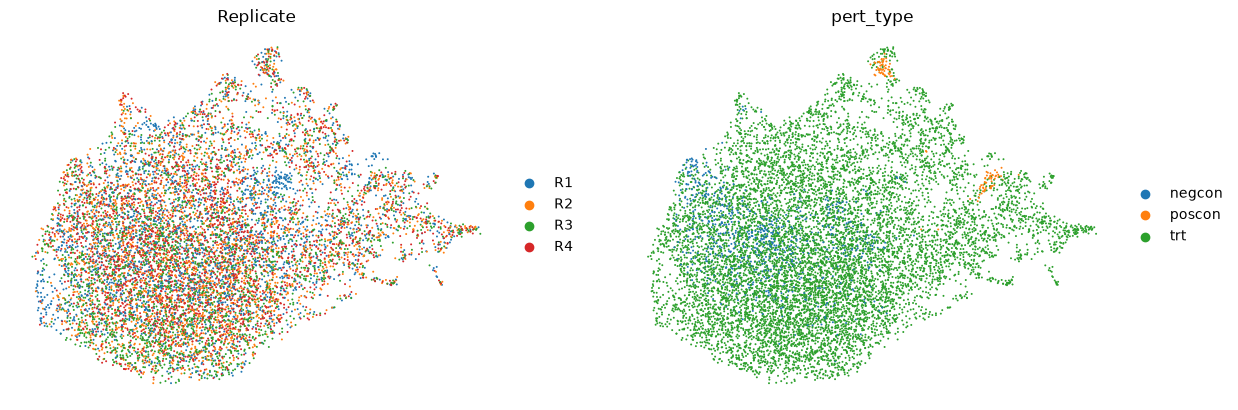

In [12]:
sc.pl.umap(adata, color=["Replicate", "pert_type"], ncols=2, frameon=False, size=8)